In [ ]:
# Student Interest Segmentation Using Machine Learning

## Project Overview

Understanding user interests is fundamental for building personalized digital products. Platforms that serve students—such as learning communities, social platforms, or campus apps—need ways to group users with similar behaviors in order to deliver relevant experiences.

This project applies **machine learning clustering techniques** to segment students based on their interests and behavioral attributes extracted from social network profiles.

The objective is to identify meaningful student groups that could inform **product personalization strategies**, community recommendations, and engagement initiatives.

---

## Problem Statement

Students often express multiple interests across areas such as sports, music, fashion, and social activities. Without structured segmentation, platforms struggle to tailor experiences effectively.

The goal of this project is to:

* Segment students into meaningful groups based on their interests
* Identify behavioral patterns across student profiles
* Evaluate multiple clustering algorithms to determine the most suitable segmentation approach

---

## Dataset

The dataset contains approximately **15,000 student social network profiles** with over **40 behavioral features**, including:

* Demographic attributes (age, gender)
* Social network metrics (number of friends)
* Interest indicators such as:

  * sports activities
  * music preferences
  * fashion and shopping
  * religion
  * lifestyle behaviors

These variables represent the frequency of keywords associated with student interests.

---

## Methodology

### 1. Data Preprocessing

Before applying clustering algorithms, the dataset required several preprocessing steps:

* Handling missing values in demographic features
* Converting categorical variables (e.g., gender) into numeric form
* Converting string-based numeric fields to numeric types
* Standardizing features to ensure equal scale across variables

Feature scaling was applied using **standardization** to prevent high-magnitude variables from dominating clustering results.

---

### 2. Exploratory Data Analysis

Exploratory analysis revealed several patterns:

* Most interest variables are sparse (many zero values)
* Students often exhibit overlapping interests
* Certain categories (sports, music, shopping) appear more frequently

These observations suggest that student personas are **not mutually exclusive**, which impacts cluster separation.

---

### 3. Clustering Algorithms Evaluated

Three clustering algorithms were tested to evaluate segmentation quality:

**K-Means Clustering**
Centroid-based clustering that partitions observations into k groups.

**Hierarchical Clustering**
Builds clusters by progressively merging similar observations.

**DBSCAN**
Density-based clustering that identifies clusters based on density of points.

Cluster quality was evaluated using the **Silhouette Score**, which measures how well observations fit within their assigned cluster relative to other clusters.

---

## Results

| Algorithm    | Silhouette Score |
| ------------ | ---------------- |
| K-Means      | **0.131**        |
| Hierarchical | 0.056            |
| DBSCAN       | -0.323           |

### Observations

* **K-Means performed best**, producing moderately separated clusters.
* Hierarchical clustering showed weaker cluster separation.
* DBSCAN struggled due to the high dimensionality and sparsity of the dataset.

This outcome is consistent with behavioral datasets where user interests overlap significantly.

---

## Cluster Insights

The clustering analysis revealed several meaningful student personas:

**Sports Enthusiasts**
Students frequently mentioning basketball, football, and other sports.

**Music & Entertainment Group**
Profiles showing high engagement with music, bands, and entertainment activities.

**Fashion & Social Lifestyle Segment**
Students interested in shopping, clothing, and lifestyle topics.

**Religious Community Segment**
Profiles showing strong association with religious keywords.

**Mixed Interest Students**
Students with balanced interests across multiple categories.

---

## Product Implications

From a product perspective, these clusters could support several features:

**Personalized Content Feeds**
Recommend content aligned with dominant student interests.

**Community Discovery**
Suggest student groups or clubs based on cluster membership.

**Event Recommendations**
Promote sports events, music concerts, or campus activities tailored to interest groups.

**Targeted Engagement Campaigns**
Segment outreach campaigns based on student personas.

---

## Key Learnings

This project highlights several important considerations when applying machine learning to user segmentation:

* Behavioral data often produces **overlapping clusters**
* Feature sparsity can impact clustering performance
* Model evaluation is critical to selecting appropriate segmentation methods
* Interpretability is essential when translating ML outputs into product decisions

---

## Future Improvements

Future enhancements could include:

* Applying dimensionality reduction techniques to improve clustering
* Using feature selection to remove noisy variables
* Incorporating behavioral activity data (e.g., app usage)
* Building dynamic clustering pipelines for real-time segmentation

---

## Conclusion

This project demonstrates how machine learning clustering techniques can uncover meaningful patterns in student interest data. While the clusters are not perfectly separated, the segmentation provides useful insights that could support personalization and engagement strategies in student-focused digital products.

The exercise illustrates the practical application of machine learning to transform raw behavioral data into actionable product insights.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.decomposition import PCA

In [4]:
df = pd.read_csv("03_Clustering_Marketing 2.csv")

df.head()

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,F,17.41,49,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2007,F,17.511,41,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,F,NaN,36,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,F,16.657,1,0,0,0,0,0,1,...,0,0,0,3,0,0,0,0,0,0


In [28]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gradyear         15000 non-null  int64  
 1   gender           0 non-null      float64
 2   age              12504 non-null  object 
 3   NumberOffriends  15000 non-null  int64  
 4   basketball       15000 non-null  int64  
 5   football         15000 non-null  int64  
 6   soccer           15000 non-null  int64  
 7   softball         15000 non-null  int64  
 8   volleyball       15000 non-null  int64  
 9   swimming         15000 non-null  int64  
 10  cheerleading     15000 non-null  int64  
 11  baseball         15000 non-null  int64  
 12  tennis           15000 non-null  int64  
 13  sports           15000 non-null  int64  
 14  cute             15000 non-null  int64  
 15  sex              15000 non-null  int64  
 16  sexy             15000 non-null  int64  
 17  hot         

,gradyear,gender,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
count,15000.000000,0.0,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2007.496933,NaN,29.834533,0.267000,0.255467,0.22200,0.159667,0.142933,0.135000,0.105133,...,0.112867,0.259467,0.357267,0.150267,0.071800,0.051467,0.185867,0.118067,0.091733,0.061067
std,1.116516,NaN,35.386649,0.788851,0.702260,0.92042,0.737344,0.638747,0.548691,0.502491,...,2.708619,0.704398,0.728512,0.478716,0.356258,0.280755,0.609928,0.455200,0.420631,0.349112
min,2006.000000,NaN,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2006.000000,NaN,3.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2008.000000,NaN,20.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2008.000000,NaN,44.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2009.000000,NaN,605.000000,22.000000,9.000000,22.00000,17.000000,14.000000,31.000000,8.000000,...,327.000000,12.000000,11.000000,8.000000,8.000000,8.000000,16.000000,14.000000,8.000000,16.000000


In [30]:
df.isnull().sum()

gradyear               0
gender             15000
age                 2496
NumberOffriends        0
basketball             0
football               0
soccer                 0
softball               0
volleyball             0
swimming               0
cheerleading           0
baseball               0
tennis                 0
sports                 0
cute                   0
sex                    0
sexy                   0
hot                    0
kissed                 0
dance                  0
band                   0
marching               0
music                  0
rock                   0
god                    0
church                 0
jesus                  0
bible                  0
hair                   0
dress                  0
blonde                 0
mall                   0
shopping               0
clothes                0
hollister              0
abercrombie            0
die                    0
death                  0
drunk                  0
drugs                  0


In [32]:
df['gender'].fillna(df['gender'].mode()[0], inplace=True)

df['age'].fillna(df['age'].median(), inplace=True)

KeyError: 0

In [34]:
df['gender'].value_counts()

Series([], Name: count, dtype: int64)

In [36]:
df['gender'].unique()

array([nan])

In [38]:
df['gender'].fillna(df['gender'].mode().iloc[0], inplace=True)

IndexError: single positional indexer is out-of-bounds

In [40]:
df['gender'].isnull().sum()

15000

In [42]:
df['gender'].replace('NA', np.nan, inplace=True)

/var/folders/dh/50q1b01x3jj6fpwv2sb3rp3r0000gn/T/ipykernel_20948/51028389.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].replace('NA', np.nan, inplace=True)


In [44]:
df['gender'] = df['gender'].replace('NA', np.nan)

In [46]:
# convert 'NA' string to actual missing values
df['gender'] = df['gender'].replace('NA', np.nan)

# fill missing values with most common gender
df['gender'] = df['gender'].fillna(df['gender'].mode().iloc[0])

# convert gender to numeric
df['gender'] = df['gender'].map({'F':0, 'M':1})

IndexError: single positional indexer is out-of-bounds

In [48]:
df['gender'].unique()

array([nan])

In [50]:
df['gender'].value_counts(dropna=False)

gender
NaN    15000
Name: count, dtype: int64

In [52]:
df['gender'].unique()

array([nan])

In [54]:
# remove spaces
df['gender'] = df['gender'].str.strip()

# convert NA-like values to NaN
df['gender'] = df['gender'].replace(['NA','na','NaN','nan',''], np.nan)

AttributeError: Can only use .str accessor with string values!

In [56]:
df['gender'] = df['gender'].astype(str)

In [58]:
df['gender'] = df['gender'].str.strip()

In [60]:
df['gender'] = df['gender'].replace(['NA','nan','NaN',''], np.nan)

/var/folders/dh/50q1b01x3jj6fpwv2sb3rp3r0000gn/T/ipykernel_20948/3044730207.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace(['NA','nan','NaN',''], np.nan)


In [62]:
df['gender'] = df['gender'].replace(['NA','nan','NaN',''], np.nan)

In [64]:
df['gender'] = df['gender'].map({'F':0,'M':1})

In [66]:
df['gender'].unique()

array([nan])

In [68]:
df['gender'].value_counts(dropna=False)

gender
NaN    15000
Name: count, dtype: int64

In [70]:
df['gender'].unique()

array([nan])

In [72]:
import numpy as np

# convert to string
df['gender'] = df['gender'].astype(str)

# normalize values
df['gender'] = df['gender'].str.strip().str.upper()

# replace NA-like values
df['gender'] = df['gender'].replace(['NA','NAN','NONE',''], np.nan)

# fill missing values with most common gender
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

/var/folders/dh/50q1b01x3jj6fpwv2sb3rp3r0000gn/T/ipykernel_20948/1513968403.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace(['NA','NAN','NONE',''], np.nan)


KeyError: 0

In [74]:
df['gender'].head(20)

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
Name: gender, dtype: float64

In [76]:
df['gender'].value_counts(dropna=False)

gender
NaN    15000
Name: count, dtype: int64

In [78]:
df = pd.read_csv("03_Clustering_Marketing 2.csv")

In [80]:
import numpy as np

df['gender'] = df['gender'].replace('NA', np.nan)

In [82]:
df['gender'] = df['gender'].fillna(df['gender'].value_counts().idxmax())

In [84]:
df['gender'] = df['gender'].replace({'F':0,'M':1})

/var/folders/dh/50q1b01x3jj6fpwv2sb3rp3r0000gn/T/ipykernel_20948/1325445074.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'F':0,'M':1})


In [86]:
df['gender'].unique()

array([0, 1])

In [88]:
df['gender'].isnull().sum()

0

In [92]:
df['gender'].unique()

array([0, 1])

In [94]:
df['gender'].dtype

dtype('int64')

In [96]:
df['age'].isnull().sum()

2496

In [98]:
df['age'] = df['age'].fillna(df['age'].median())

TypeError: Cannot convert [nan '17.41' '17.511' ... '17.999' '17.903' '15.811'] to numeric

In [100]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [102]:
df['age'] = df['age'].fillna(df['age'].median())

In [104]:
df['age'].dtype

dtype('float64')

In [106]:
df['age'].isnull().sum()

0

In [108]:
# convert age to numeric
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# fill missing values with median
df['age'] = df['age'].fillna(df['age'].median())

In [110]:
df.describe()

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,...,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2007.496933,0.173733,17.860068,29.834533,0.267000,0.255467,0.22200,0.159667,0.142933,0.135000,...,0.112867,0.259467,0.357267,0.150267,0.071800,0.051467,0.185867,0.118067,0.091733,0.061067
std,1.116516,0.378893,6.971667,35.386649,0.788851,0.702260,0.92042,0.737344,0.638747,0.548691,...,2.708619,0.704398,0.728512,0.478716,0.356258,0.280755,0.609928,0.455200,0.420631,0.349112
min,2006.000000,0.000000,4.309000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2006.000000,0.000000,16.545000,3.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2008.000000,0.000000,17.295000,20.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2008.000000,0.000000,18.056000,44.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2009.000000,1.000000,106.927000,605.000000,22.000000,9.000000,22.00000,17.000000,14.000000,31.000000,...,327.000000,12.000000,11.000000,8.000000,8.000000,8.000000,16.000000,14.000000,8.000000,16.000000


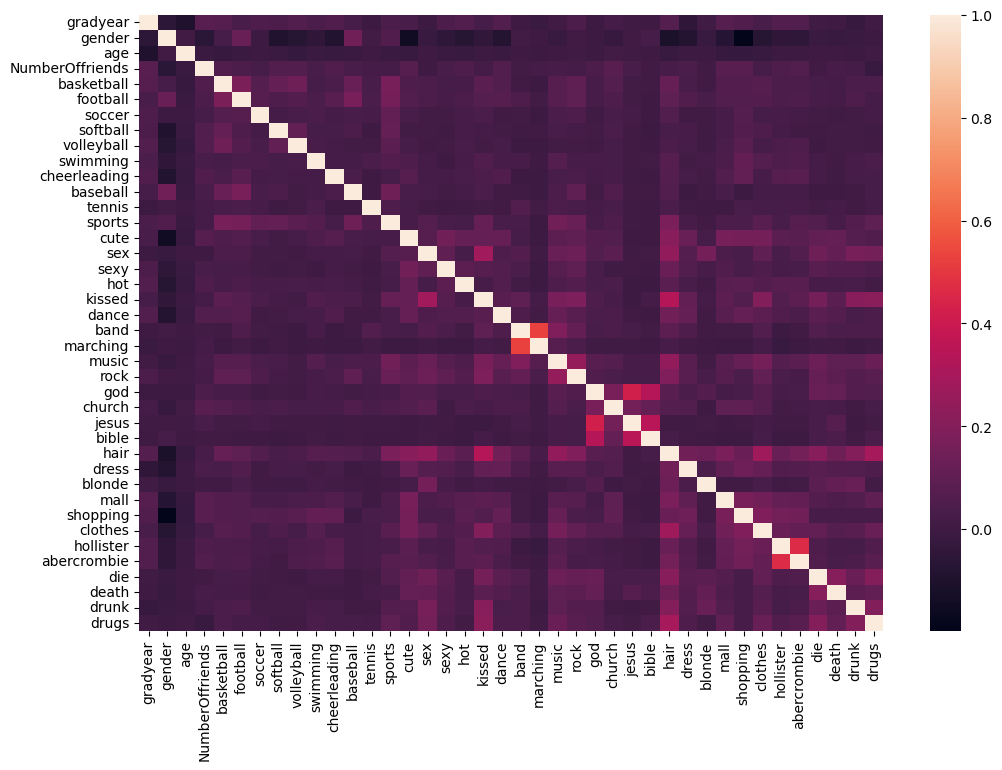

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr())
plt.show()

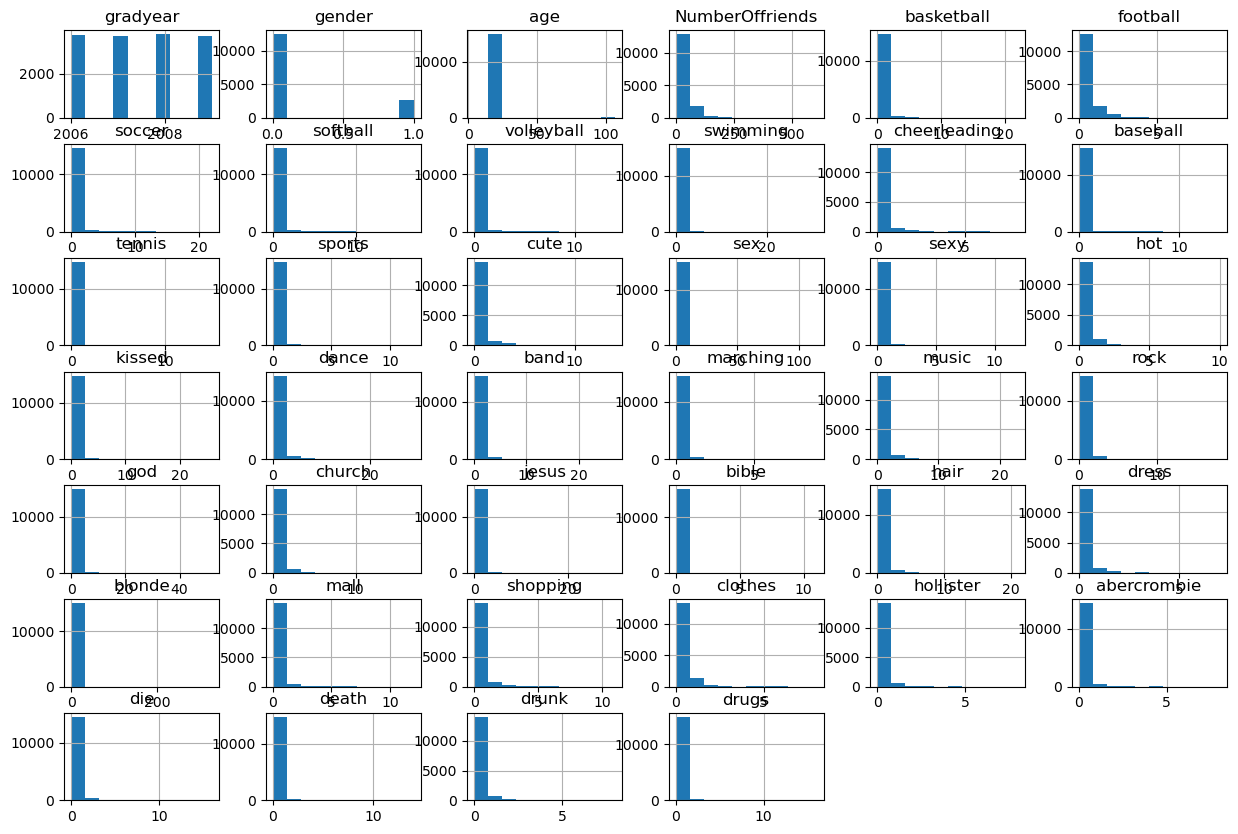

In [116]:
df.hist(figsize=(15,10))
plt.show()

In [118]:
df.skew()

gradyear             0.000791
gender               1.722441
age                 11.664522
NumberOffriends      2.724171
basketball           5.681317
football             4.117243
soccer               7.277183
softball             7.842373
volleyball           7.548032
swimming            16.380904
cheerleading         6.917809
baseball             9.344208
tennis              11.236150
sports               5.877223
cute                 4.155413
sex                 49.972125
sexy                 6.678510
hot                  5.685510
kissed              12.866542
dance                5.728317
band                 7.413696
marching            11.670519
music                4.378561
rock                 6.450876
god                 11.490218
church               5.549156
jesus               19.160195
bible               21.417635
hair                 4.637419
dress                5.546623
blonde             117.250830
mall                 4.697283
shopping             2.935774
clothes   

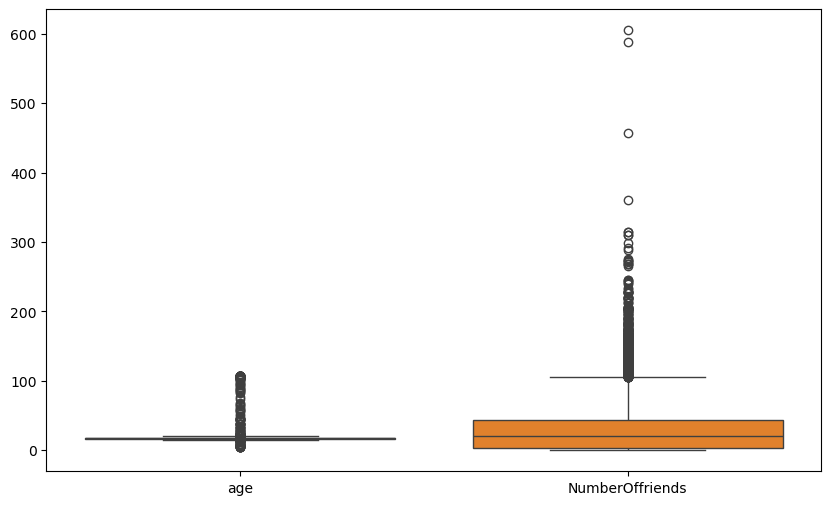

In [120]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['age','NumberOffriends']])
plt.show()

In [122]:
df = df[df['NumberOffriends'] < 5000]

In [124]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

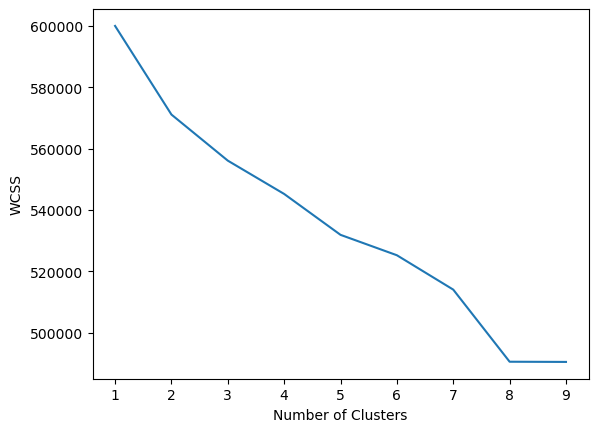

In [126]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [128]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)

kmeans_labels = kmeans.fit_predict(X_scaled)

df['kmeans_cluster'] = kmeans_labels

In [130]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, kmeans_labels)

print("Silhouette Score:", score)

Silhouette Score: 0.0833756838376776


In [132]:
df_clustering = df.drop(columns=['gradyear'])

In [134]:
df_clustering.sum().sort_values()

bible                 312.000
marching              632.000
abercrombie           772.000
drugs                 916.000
hollister            1077.000
tennis               1323.000
drunk                1376.000
baseball             1562.000
kissed               1571.000
cheerleading         1577.000
jesus                1682.000
blonde               1693.000
dress                1747.000
death                1771.000
hot                  1899.000
swimming             2025.000
sexy                 2073.000
volleyball           2144.000
sports               2155.000
clothes              2254.000
softball             2395.000
gender               2606.000
die                  2788.000
sex                  3219.000
soccer               3330.000
church               3670.000
rock                 3688.000
football             3832.000
mall                 3892.000
basketball           4005.000
band                 4529.000
cute                 4921.000
shopping             5359.000
dance     

In [136]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_clustering)

In [138]:
kmeans = KMeans(n_clusters=4, random_state=42)

labels = kmeans.fit_predict(X_scaled)

In [140]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)

print(score)

0.13139921669891624


In [142]:
silhouette_score(X_scaled, kmeans_labels)

0.13302129640568902

In [144]:
from sklearn.cluster import AgglomerativeClustering

hier = AgglomerativeClustering(n_clusters=4)

hier_labels = hier.fit_predict(X_scaled)

from sklearn.metrics import silhouette_score

silhouette_score(X_scaled, hier_labels)

0.055728448355185936

In [146]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)

db_labels = db.fit_predict(X_scaled)

silhouette_score(X_scaled, db_labels)

-0.32311424823489954

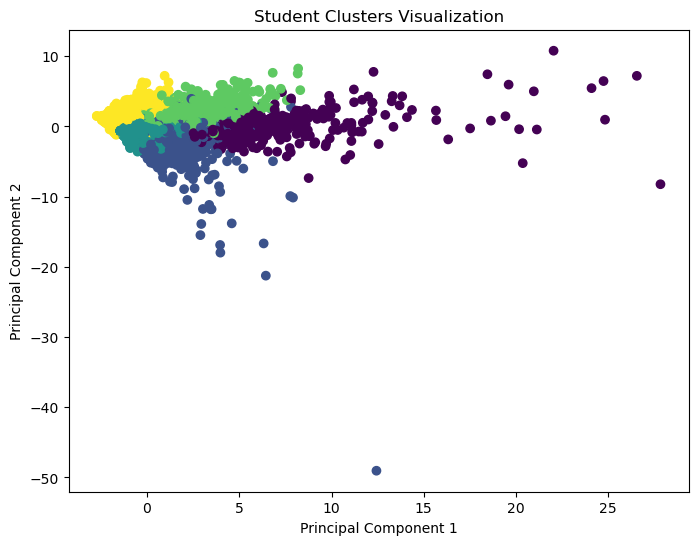

In [151]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, cmap='viridis')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Student Clusters Visualization")

plt.show()

In [153]:
cluster_profile = df.groupby('kmeans_cluster').mean()

cluster_profile

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
kmeans_cluster,,,,,,,,,,,,,,,,,,,,,
0,2007.665392,0.128107,17.681870,30.239006,0.623327,0.575526,0.409178,0.233270,0.196941,0.260038,...,1.183556,0.728489,0.537285,0.734226,0.175908,0.168260,1.246654,0.539197,0.900574,0.975143
1,2007.710526,0.057416,17.502425,43.580542,0.950558,0.525518,0.897927,1.111643,0.904306,0.221691,...,0.148325,0.291069,0.488836,0.181021,0.038278,0.027911,0.209729,0.178628,0.071770,0.045455
2,2007.436323,0.000000,17.385964,27.114157,0.132995,0.118443,0.123858,0.068697,0.066667,0.095544,...,0.055499,0.146870,0.249408,0.070953,0.016808,0.008460,0.127806,0.086633,0.056289,0.024591
3,2007.775741,0.015633,17.342546,41.396226,0.340701,0.412399,0.238275,0.136927,0.133693,0.309973,...,0.193531,0.857682,1.164420,0.475472,0.392992,0.290027,0.224798,0.160108,0.099730,0.039353
4,2007.362765,0.974031,20.139176,23.929684,0.270076,0.422293,0.179784,0.006392,0.027167,0.075509,...,0.014782,0.101079,0.037555,0.052737,0.023572,0.014383,0.129045,0.079904,0.052337,0.023172


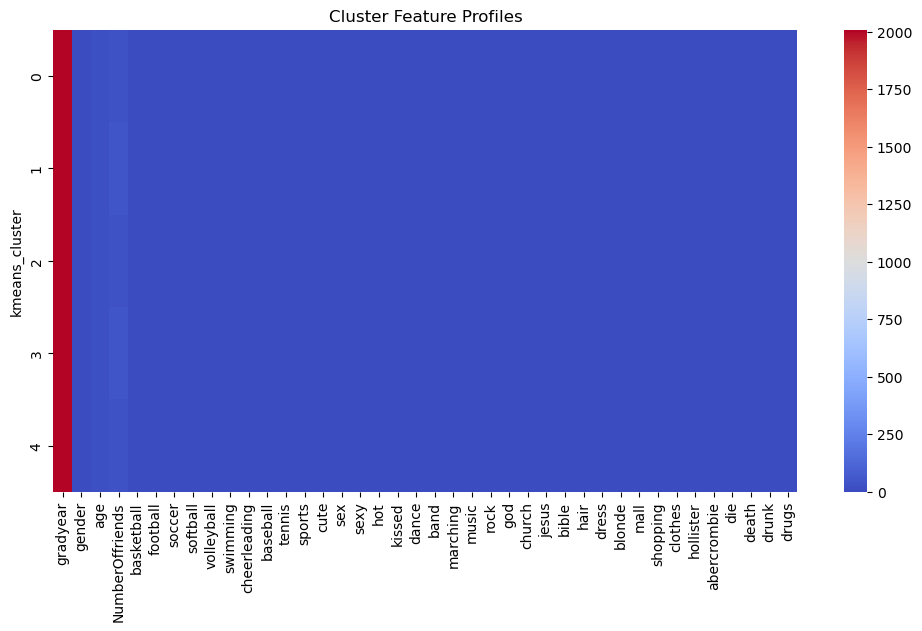

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(cluster_profile, cmap="coolwarm")

plt.title("Cluster Feature Profiles")

plt.show()